
### DS 3026 Final Project - Section 3
# Part 3: Frequentist Estimation and Testing

**Inferential Question:** Does the home team have an advantage in NBA games? If it exists, has the home-court advantage changed in the modern era (post-2018)?

<!-- What is the true long-run probability that the home team wins an NBA game? Has the home-court advantage changed in the modern era (post-2018)? -->

**Parameter of Interest:** π = true home-win probability

**Estimator:** p̂ = (number of home wins) / (total games)

In [21]:
#import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

### Data loading

In [22]:
game_df = pd.read_csv('game_df.csv')

#Filter to Regular Season games only for clean inference
reg_season = game_df[game_df['season_type'] == 'Regular Season'].copy()
#setting up the target of win and loss
# Binary outcome: 1 = home win, 0 = home loss
reg_season['home_win'] = (reg_season['wl_home'] == 'W').astype(int)
reg_season['pt_diff']  = reg_season['pts_home'] - reg_season['pts_away']

# Extract season year from season_id, which is found in last four digits
reg_season['season_year'] = reg_season['season_id'].astype(str).str[-4:].astype(int)
#creating key variables for the total games, wins and probability
n_total  = len(reg_season)
n_wins   = reg_season['home_win'].sum()
p_hat    = n_wins / n_total

### Sampling Distribution Reasoning

We model each game as an independent Bernoulli trial with unknown success probability π.  
The MLE is p̂ = X/n. Using Centeral Limit Theorem



0.0030554960464515744
0.003115642781973398


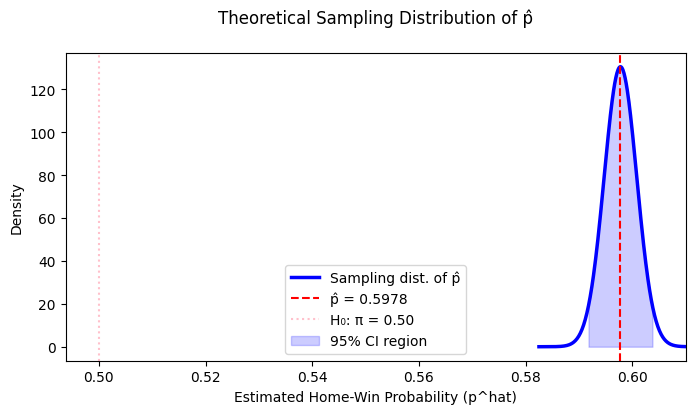

In [23]:
#theoretical standard error under MLE
se_mle = np.sqrt(p_hat * (1 - p_hat) / n_total)

#standard error under null, pi = .5
se_null = np.sqrt(0.5 * 0.5 / n_total)

#checking results
print(se_mle)
print(se_null)

# Visualize the theoretical sampling distribution
fig, ax = plt.subplots(figsize=(8, 4))
#setting the graph proportions right for x and y
x = np.linspace(p_hat - 5 * se_mle, p_hat + 5 * se_mle, 300)
y = stats.norm.pdf(x, p_hat, se_mle)
ax.set_xlim(p_hat - 5 * se_mle, p_hat + 5 * se_mle)
ax.set_xlim(min(0.5 - 2*se_null, p_hat - 4*se_mle),
            max(0.5 + 2*se_null, p_hat + 4*se_mle))
#plotting
ax.plot(x, y, color='blue', lw=2.5, label='Sampling dist. of p̂')
ax.axvline(p_hat, color='red', ls='--', lw=1.5, label=f'p̂ = {p_hat:.4f}')
ax.axvline(0.5, color='pink', ls=':', lw=1.5, label='H₀: π = 0.50')

#shade 95% region
ci_lo = p_hat - 1.96 * se_mle
ci_hi = p_hat + 1.96 * se_mle
x_shade = np.linspace(ci_lo, ci_hi, 300)
ax.fill_between(x_shade, stats.norm.pdf(x_shade, p_hat, se_mle),
                alpha=0.2, color='blue', label='95% CI region')
#labeling
ax.set_xlabel('Estimated Home-Win Probability (p^hat)')
ax.set_ylabel('Density')
ax.set_title('Theoretical Sampling Distribution of p̂\n')

ax.legend()
plt.show()

### Confidence Intervals

**Using boostraping**: resample the data, refit the model, repeat many times, then take the 2.5th and 97.5th percentiles of the resulting distribution

Bootstrap 95% CI for pi: (0.591714, 0.603790)


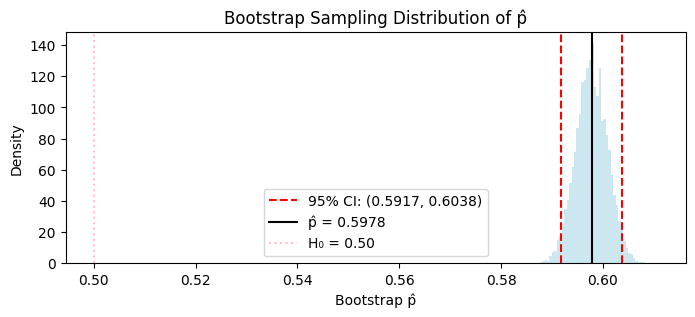

In [24]:
#Bootstrap CI for home-win probability
#setting n size
n_boot = 10000
boot_props = np.zeros(n_boot)

for i in range(n_boot):
    #resample wins
    boot_sample = np.random.binomial(n_total, p_hat)
    #refit "model" (p̂)
    boot_props[i] = boot_sample / n_total

#95% bootstrap CI
boot_lo = np.percentile(boot_props, 2.5)
boot_hi = np.percentile(boot_props, 97.5)

print(f'Bootstrap 95% CI for pi: ({boot_lo:.6f}, {boot_hi:.6f})')

# Plot
fig, ax = plt.subplots(figsize=(8, 3))
#setting boostrap and coolors
ax.hist(boot_props, bins=50, color='lightblue', alpha=0.6, density=True)
ax.axvline(boot_lo, color='red', ls='--', lw=1.5, label=f'95% CI: ({boot_lo:.4f}, {boot_hi:.4f})')
ax.axvline(boot_hi, color='red', ls='--', lw=1.5)
ax.axvline(p_hat,   color='black', ls='-',  lw=1.5, label=f'p̂ = {p_hat:.4f}')
ax.axvline(0.5,     color='pink', ls=':', lw=1.5, label='H₀ = 0.50')
#labeling
ax.set_xlabel('Bootstrap p̂')
ax.set_ylabel('Density')
ax.set_title('Bootstrap Sampling Distribution of p̂')
#printing
ax.legend()
plt.show()

**Theory CI: Wald**

Nearly identical to bootstrap: n is large enough that the CLT has kicked in fully.

The 95% confidence interval suggests that the true home-win probability π falls between 0.5918 and 0.6038. Since the entire interval is above 0.50, this gives strong evidence that home teams win more than half the time.

In [25]:
ci_lo = p_hat - 1.96 * se_mle
ci_hi = p_hat + 1.96 * se_mle

print(f'Wald 95% CI for pi: ({ci_lo:.6f}, {ci_hi:.6f})')

Wald 95% CI for pi: (0.591782, 0.603760)


### Hypothesis Testing

**Test 1: Does a Home-Court Advantage Exist?**

H_0: pi = 0.5

H_1: pi > 0.5

Interpretation: With Z = 32.0 and p around 0, we reject H0 at every
conventional significance level. There is overwhelming evidence that NBA home teams win more than 50% of regular season games (p̂ = 0.5978).


In [26]:
# One-sided z-test: H1: pi > 0.5
z_stat, p_val = proportions_ztest(n_wins, n_total, value=0.5, alternative='larger')
print(f'Test statistic Z  = {z_stat:.4f}')
print(f'P-value           = {p_val:.2e}')
print(f'Decision (α=0.05): {"Reject H0" if p_val < 0.05 else "Fail to reject H0"}')

Test statistic Z  = 31.9985
P-value           = 5.72e-225
Decision (α=0.05): Reject H0


**Test 2: Has Home-Court Advantage Declined in the Modern Era?**

The 2019–2021 seasons (COVID bubble, restricted attendance) may have reduced home-court advantage. We test whether the pre-2019 and post-2018 home-win rates differ.

H_0: pi_new = pi_old

H_1: pi_new /= pi_old

In [27]:
#Split into pre-2019 (traditional) and 2019+ (modern/bubble) era
era_old = reg_season[reg_season['season_year'] <  2019]
era_new = reg_season[reg_season['season_year'] >= 2019]
#calculating p_hat of new and old eras
n_old, wins_old = len(era_old), era_old['home_win'].sum()
n_new, wins_new = len(era_new), era_new['home_win'].sum()
p_old = wins_old / n_old
p_new = wins_new / n_new

# Two-sample z-test for proportions
z2, p2 = proportions_ztest([wins_old, wins_new], [n_old, n_new], alternative='two-sided')

#CIs for each era
ci_old = proportion_confint(wins_old, n_old, method='wilson')
ci_new = proportion_confint(wins_new, n_new, method='wilson')

print(f'Z = {z2:.4f},  p-value = {p2:.4f}')
print(f'Decision (α=0.05): {"Reject H0" if p2 < 0.05 else "Fail to reject H0"}')
print()
print(f'Pre-2019 95% CI: ({ci_old[0]:.4f}, {ci_old[1]:.4f})')
print(f'2019+ 95% CI: ({ci_new[0]:.4f}, {ci_new[1]:.4f})')

Z = 5.3163,  p-value = 0.0000
Decision (α=0.05): Reject H0

Pre-2019 95% CI: (0.5981, 0.6111)
2019+ 95% CI: (0.5437, 0.5749)


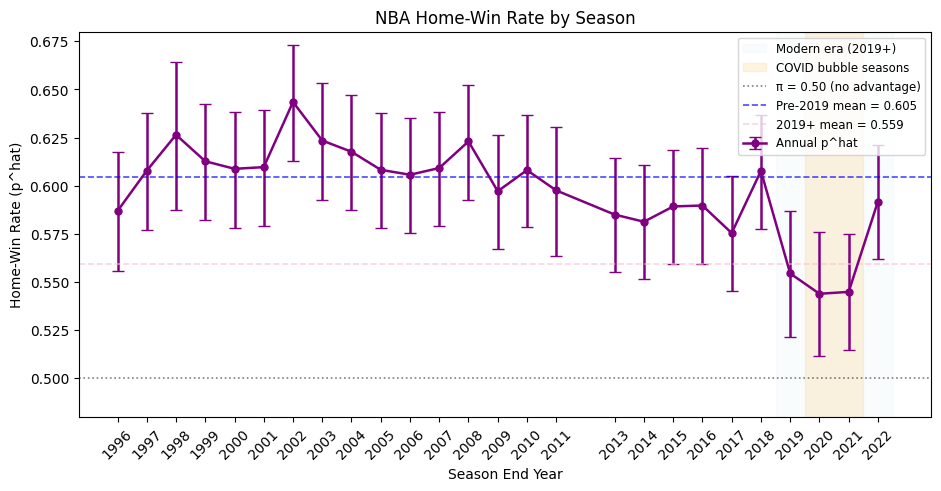

In [28]:
#Visualize home-win rate by season with era bands
annual = reg_season.groupby('season_year')['home_win'].agg(['mean','count','sum']).reset_index()
annual.columns = ['year','p_hat','n','wins']

#Adding CI per season
annual['ci_lo'] = annual.apply(lambda r: proportion_confint(r['wins'], r['n'], method='wilson')[0], axis=1)
annual['ci_hi'] = annual.apply(lambda r: proportion_confint(r['wins'], r['n'], method='wilson')[1], axis=1)

fig, ax = plt.subplots(figsize=(11, 5))

#Adding era shading
ax.axvspan(2018.5, annual['year'].max() + 0.5, alpha=0.07, color='lightblue', label='Modern era (2019+)')
ax.axvspan(2019.5, 2021.5, alpha=0.12, color='orange', label='COVID bubble seasons')

# Adding error bars
ax.errorbar(annual['year'], annual['p_hat'],
            yerr=[annual['p_hat'] - annual['ci_lo'], annual['ci_hi'] - annual['p_hat']],
            fmt='o-', color='purple', capsize=4, ms=5, lw=1.8, label='Annual p^hat')

# Reference lines
ax.axhline(0.5,    color='black',            ls=':',  lw=1.2, alpha=0.5, label='π = 0.50 (no advantage)')
ax.axhline(p_old,  color='blue',  ls='--', lw=1.2, alpha=0.7, label=f'Pre-2019 mean = {p_old:.3f}')
ax.axhline(p_new,  color='pink', ls='--', lw=1.2, alpha=0.7, label=f'2019+ mean = {p_new:.3f}')

ax.set_xlabel('Season End Year')
ax.set_ylabel('Home-Win Rate (p^hat)')
ax.set_title('NBA Home-Win Rate by Season')
ax.set_ylim(0.48, 0.68)
ax.legend(fontsize=8.5, loc='upper right')
ax.set_xticks(annual['year'])
ax.tick_params(axis='x', rotation=45)
plt.show()